# Análisis de Propagación de Spikes — Branching Ratio 2D Sweep
> **Objetivo:** Estimar cómo distintos niveles de acoplamiento `K` y tasas de input `rate_hz`
> modulan la propagación sináptica (branching ratio σ) en una red E/I de Izhikevich.

Métricas calculadas:
- `sigma_global` — estimador Beggs & Plenz (macroscópico)
- `sigma_global_corr` — corrección drive externo (Wilting & Priesemann 2018)
- `sigma_micro_EE` — tracking causal E→E, tiempo continuo (Numba)
- `p_prop_EE` — probabilidad de activar un vecino específico

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 1 — Setup e Imports
# ══════════════════════════════════════════════════════════════════════════════

import os
import sys

# ── Restricción de hilos (ANTES de cualquier import numérico) ─────────────────
for var in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
            "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[var] = "1"

import gzip
import pickle
import multiprocessing as mp
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors as mcolors
import seaborn as sns
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm
from loguru import logger

# ── Multiprocessing: fork hereda el JIT de Numba ya compilado ─────────────────
# spawn recrearía el proceso desde cero → recompila kernels en cada worker
# En Linux el default ya es fork, pero lo hacemos explícito:
try:
    mp.set_start_method('fork', force=True)
except RuntimeError:
    pass  # ya fue inicializado en la sesión actual

# ── Root del proyecto ─────────────────────────────────────────────────────────
current_path = Path.cwd()
root_path = None
for p in [current_path] + list(current_path.parents):
    if (p / 'src').exists():
        root_path = p
        os.chdir(p)
        break
if root_path is None:
    logger.warning("No se encontró 'src/'. Asegúrate de estar en el proyecto.")
else:
    if str(root_path) not in sys.path:
        sys.path.insert(0, str(root_path))
    logger.info(f"Root: {root_path}")

# ── Imports del proyecto ──────────────────────────────────────────────────────
try:
    from src.two_populations.model import IzhikevichNetwork
    from src.two_populations.metrics import analyze_simulation_results
    from src.two_populations.helpers.logger import setup_logger
    logger = setup_logger(
        experiment_name="spike_propagation_analysis",
        console_level="INFO", file_level="DEBUG", log_to_file=False)
except ImportError as e:
    logger.warning(f"Módulos locales no disponibles: {e}")

# ── Import del script de re-análisis ─────────────────────────────────────────
# Ajusta la ruta si el script está en otro directorio
sys.path.insert(0, str(root_path / 'notebooks' / 'two_populations'))
from spike_propagation_reanalysis import (
    load_sweep_index, load_raw_sim,
    build_spike_dict, build_population_activity, build_neighbors,
    sigma_global, sigma_corrected_k0, sigma_micro, sigma_vs_binsize,
    analyze_single_sim, reanalyze_sweep, aggregate_results, save_results,
    plot_sigma_comparison, plot_delta_p,
    NUMBA_AVAILABLE,
)
logger.info(f"Numba disponible: {NUMBA_AVAILABLE}")

# ── Estilo de plots ───────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

logger.info(f"Setup completado — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


2026-02-20 16:20:12.845 | INFO     | __main__:<module>:51 - Root: /home/tonicoll/Projects/izhikevich
/home/tonicoll/.conda/envs/neurophysics/lib/python3.11/site-packages/setuptools/_distutils/_msvccompiler.py:12: UserWarning: _get_vc_env is private; find an alternative (pypa/distutils#340)
  warnings.warn(
INFO     | __main__:<module>:75 - Numba disponible: True
INFO     | __main__:<module>:89 - Setup completado — 2026-02-20 16:20:14


In [2]:
"""
CELDAS DE ANÁLISIS COMBINATORIO
================================
Reemplaza las celdas 1, 4 y 5 del notebook por un sistema que:
  - Codifica todos los parámetros en el nombre del pkl
  - Evita recalcular si el resultado ya existe
  - Corre las 4 combinaciones de forma sistemática
  - Genera tabla comparativa
  
Copiar cada bloque marcado como CELDA X en la celda correspondiente del notebook.
"""

# ══════════════════════════════════════════════════════════════════════════════
# CELDA A — Helpers de naming y caché
# (insertar después de la celda de imports, antes de la celda de configuración)
# ══════════════════════════════════════════════════════════════════════════════

def make_run_tag(causal_weighting: bool, baseline_correction: str,
                 weight_norm: bool = False) -> str:
    """
    Genera un tag único que codifica todos los parámetros de análisis.
    
    Ejemplos:
        (False, None,     False) → 'cw0_bc0_wn0'
        (True,  'poisson',True)  → 'cw1_bcp_wn1'
    """
    cw  = 'cw1'  if causal_weighting      else 'cw0'
    bc  = 'bcp'  if baseline_correction == 'poisson' else 'bc0'
    wn  = 'wn1'  if weight_norm            else 'wn0'
    return f'{cw}_{bc}_{wn}'


def load_or_compute(sweep_dir, cfg, tag, causal_weighting,
                    baseline_correction, n_processes,
                    force_recompute=False):
    """
    Carga resultados si existen para este tag exacto, o los computa.
    
    El pkl se llama: reanalysis_{tag}.pkl
    Así cw0_bc0_wn0 y cw1_bc0_wn0 nunca colisionan.
    """
    pkl_path = sweep_dir / f'reanalysis_{tag}.pkl'
    
    if pkl_path.exists() and not force_recompute:
        logger.info(f"[{tag}] Cargando desde caché: {pkl_path.name}")
        with open(pkl_path, 'rb') as f:
            saved = pickle.load(f)
        # Verificar que los parámetros del pkl coinciden con los solicitados
        saved_cfg = saved.get('config', {})
        if saved_cfg.get('_causal_weighting') != causal_weighting:
            logger.warning(f"[{tag}] ADVERTENCIA: causal_weighting en pkl "
                           f"({saved_cfg.get('_causal_weighting')}) != "
                           f"solicitado ({causal_weighting}). Recalculando.")
        else:
            return saved['df_raw'], saved['df_aggregated']
    
    logger.info(f"[{tag}] Calculando (cw={causal_weighting}, bc={baseline_correction})...")
    df_raw = reanalyze_sweep(
        sweep_dir=sweep_dir,
        cfg=cfg,
        run_bin_sweep=False,
        causal_weighting=causal_weighting,
        baseline_correction=baseline_correction,
        n_processes=n_processes,
    )
    df_agg = aggregate_results(df_raw)
    
    # Guardar con metadatos de parámetros en el config
    cfg_with_meta = {**cfg,
                     '_causal_weighting':    causal_weighting,
                     '_baseline_correction': baseline_correction,
                     '_tag':                 tag}
    save_results(df_raw, df_agg, sweep_dir, cfg_with_meta, tag=tag)
    return df_raw, df_agg


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA B — Correr las 4 combinaciones sistemáticamente
# (reemplaza celdas 4 y 5 del notebook)
# ══════════════════════════════════════════════════════════════════════════════

SWEEP_DIR = Path('results/spike_propagation_2d/sweep_2d_20260216_134903')  # ← EDITAR

REANALYSIS_CONFIG = {
    'Ne': 800,
    'Ni': 200,
    'dt_sim_ms': 0.1,
    'T_ms': 4000,
    'warmup_ms': 500,
    'dt_bin_ms': 1.0,        # solo para sigma_global y A(t)
    'window_ms': 4.0,        # ventana monosináptica
    'min_spikes_ancestor': 3,
    'bin_sweep': [0.5, 1.0, 2.0, 4.0],
}

N_PROCESSES = 14

# Las 4 combinaciones del sweep actual (weight_normalization=False)
COMBINATIONS = [
    # (causal_weighting, baseline_correction, descripción)
    (False, None,      'Sin CW, sin Poisson   [referencia]'),
    (False, 'poisson', 'Sin CW, con Poisson   [corrección micro]'),
    (True,  None,      'Con CW, sin Poisson   [crédito causal]'),
    (True,  'poisson', 'Con CW, con Poisson   [combinado]'),
]

# Diccionario de resultados indexado por tag
WEIGHT_NORM = False  # ← cambiar a True cuando uses el sweep normalizado
results = {}

for cw, bc, desc in COMBINATIONS:
    tag = make_run_tag(cw, bc, WEIGHT_NORM)
    logger.info(f"\n{'─'*55}")
    logger.info(f"Combinación: {desc}  [tag={tag}]")
    df_r, df_a = load_or_compute(
        sweep_dir=SWEEP_DIR,
        cfg=REANALYSIS_CONFIG,
        tag=tag,
        causal_weighting=cw,
        baseline_correction=bc,
        n_processes=N_PROCESSES,
        force_recompute=False,  # ← True para forzar recálculo
    )
    results[tag] = {
        'df_raw':  df_r,
        'df_agg':  df_a,
        'cw':      cw,
        'bc':      bc,
        'desc':    desc,
    }
    logger.info(f"  [OK] {tag}: {len(df_r)} sims, {len(df_a)} condiciones")

logger.info(f"\n{'='*55}")
logger.info(f"Resultados disponibles: {list(results.keys())}")

INFO     | __main__:<module>:37 - 
───────────────────────────────────────────────────────
INFO     | __main__:<module>:38 - Combinación: Sin CW, sin Poisson   [referencia]  [tag=cw0_bc0_wn0]
INFO     | __main__:load_or_compute:57 - [cw0_bc0_wn0] Calculando (cw=False, bc=None)...



  Re-análisis de propagación de spikes  (v3 — Numba:True)
  causal_weighting   : False
  baseline_correction: None
  Sweep: results/spike_propagation_2d/sweep_2d_20260216_134903

  K values   : 25  (0.0 – 15.0)
  rate_hz    : 25 (2.0 – 25.0)
  Trials     : 4
  Total sims : 2500

── Pasada 1: calculando baselines k=0 ──


k=0 baseline: 100%|██████████| 100/100 [00:02<00:00, 45.95it/s]


  Baselines listos para 25 valores de rate_hz

── Pasada 2: análisis completo (multiprocessing) ──


Simulaciones: 100%|██████████| 2500/2500 [01:20<00:00, 31.18it/s]
INFO     | __main__:<module>:55 -   [OK] cw0_bc0_wn0: 2500 sims, 625 condiciones
INFO     | __main__:<module>:37 - 
───────────────────────────────────────────────────────
INFO     | __main__:<module>:38 - Combinación: Sin CW, con Poisson   [corrección micro]  [tag=cw0_bcp_wn0]
INFO     | __main__:load_or_compute:57 - [cw0_bcp_wn0] Calculando (cw=False, bc=poisson)...


...


  Simulaciones procesadas: 2500
  Columnas: ['k', 'rate_hz', 'trial', 'firing_rate_exc', 'firing_rate_inh', 'firing_rate_all', 'n_spikes_exc', 'n_spikes_inh', 'sigma_global', 'sigma_global_corr', 'A_mean', 'sigma_micro_EE', 'p_prop_EE', 'n_spikes_analyzed_EE', 'sigma_micro_Eall', 'p_prop_Eall', 'n_spikes_analyzed_Eall', 'p_base']

  Guardado: results/spike_propagation_2d/sweep_2d_20260216_134903/reanalysis_propagation_cw1_bc0_wn0.pkl
  CSV:      results/spike_propagation_2d/sweep_2d_20260216_134903/reanalysis_aggregated_cw1_bc0_wn0.csv


  Re-análisis de propagación de spikes  (v3 — Numba:True)
  causal_weighting   : True
  baseline_correction: poisson
  Sweep: results/spike_propagation_2d/sweep_2d_20260216_134903

  K values   : 25  (0.0 – 15.0)
  rate_hz    : 25 (2.0 – 25.0)
  Trials     : 4
  Total sims : 2500

── Pasada 1: calculando baselines k=0 ──


k=0 baseline: 100%|██████████| 100/100 [00:02<00:00, 47.21it/s]

  Baselines listos para 25 valores de rate_hz

── Pasada 2: análisis completo (multiprocessing) ──



Simulaciones: 100%|██████████| 2500/2500 [23:39<00:00,  1.76it/s]
INFO     | __main__:<module>:55 -   [OK] cw1_bcp_wn0: 2500 sims, 625 condiciones
INFO     | __main__:<module>:57 - 
INFO     | __main__:<module>:58 - Resultados disponibles: ['cw0_bc0_wn0', 'cw0_bcp_wn0', 'cw1_bc0_wn0', 'cw1_bcp_wn0']



  Simulaciones procesadas: 2500
  Columnas: ['k', 'rate_hz', 'trial', 'firing_rate_exc', 'firing_rate_inh', 'firing_rate_all', 'n_spikes_exc', 'n_spikes_inh', 'sigma_global', 'sigma_global_corr', 'A_mean', 'sigma_micro_EE', 'p_prop_EE', 'n_spikes_analyzed_EE', 'sigma_micro_Eall', 'p_prop_Eall', 'n_spikes_analyzed_Eall', 'p_base']

  Guardado: results/spike_propagation_2d/sweep_2d_20260216_134903/reanalysis_propagation_cw1_bcp_wn0.pkl
  CSV:      results/spike_propagation_2d/sweep_2d_20260216_134903/reanalysis_aggregated_cw1_bcp_wn0.csv



In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA C — Tabla comparativa de métricas clave
# ══════════════════════════════════════════════════════════════════════════════

# Métricas a comparar en el régimen Activo (FR_exc > 0.5 Hz y < 40 Hz)
METRICS_TO_COMPARE = [
    ('sigma_micro_EE',   'σ micro EE'),
    ('sigma_global',     'σ global'),
    ('sigma_global_corr','σ global corr.'),
    ('p_prop_EE',        'p_prop EE'),
    ('p_prop_Eall',      'p_prop Eall'),
]

print(f"\n{'═'*90}")
print(f"  TABLA COMPARATIVA — régimen Activo (FR_exc ∈ [0.5, 40] Hz)")
print(f"{'═'*90}")
print(f"  {'Tag':<14} {'Descripción':<35} {'Métrica':<20} {'Media':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print(f"  {'─'*90}")

for tag, res in results.items():
    df_r = res['df_raw']
    # Filtrar régimen Activo
    mask_active = (df_r['firing_rate_exc'] >= 0.5) & (df_r['firing_rate_exc'] <= 40.0)
    df_active   = df_r[mask_active]
    
    if len(df_active) == 0:
        print(f"  {tag:<14} {res['desc']:<35} {'(sin datos activos)'}")
        continue
    
    first = True
    for col, label in METRICS_TO_COMPARE:
        if col not in df_active.columns:
            continue
        vals = df_active[col].dropna()
        if len(vals) == 0:
            continue
        tag_str  = tag  if first else ''
        desc_str = res['desc'] if first else ''
        print(f"  {tag_str:<14} {desc_str:<35} {label:<20} "
              f"{vals.mean():>8.4f} {vals.std():>8.4f} "
              f"{vals.min():>8.4f} {vals.max():>8.4f}")
        first = False
    print(f"  {'─'*90}")

print(f"\n  N simulaciones en régimen Activo por combinación:")
for tag, res in results.items():
    df_r    = res['df_raw']
    mask    = (df_r['firing_rate_exc'] >= 0.5) & (df_r['firing_rate_exc'] <= 40.0)
    n_act   = mask.sum()
    n_total = len(df_r)
    print(f"    {tag:<14}: {n_act:>5}/{n_total} ({n_act/n_total*100:.1f}%)")



══════════════════════════════════════════════════════════════════════════════════════════
  TABLA COMPARATIVA — régimen Activo (FR_exc ∈ [0.5, 40] Hz)
══════════════════════════════════════════════════════════════════════════════════════════
  Tag            Descripción                         Métrica                 Media      Std      Min      Max
  ──────────────────────────────────────────────────────────────────────────────────────────
  cw0_bc0_wn0    Sin CW, sin Poisson   [referencia]  σ micro EE            14.2995   7.1067   0.1364  30.8511
                                                     σ global               1.1239   0.0891   0.3161   1.3346
                                                     σ global corr.        -0.1463   0.5085  -0.9960   1.1498
                                                     p_prop EE              0.1711   0.0830   0.0016   0.3813
                                                     p_prop Eall            0.1834   0.0839   0.0043   0.3857
  ─

INFO     | __main__:<module>:14 - Rate de referencia para comparación: 9.67 Hz


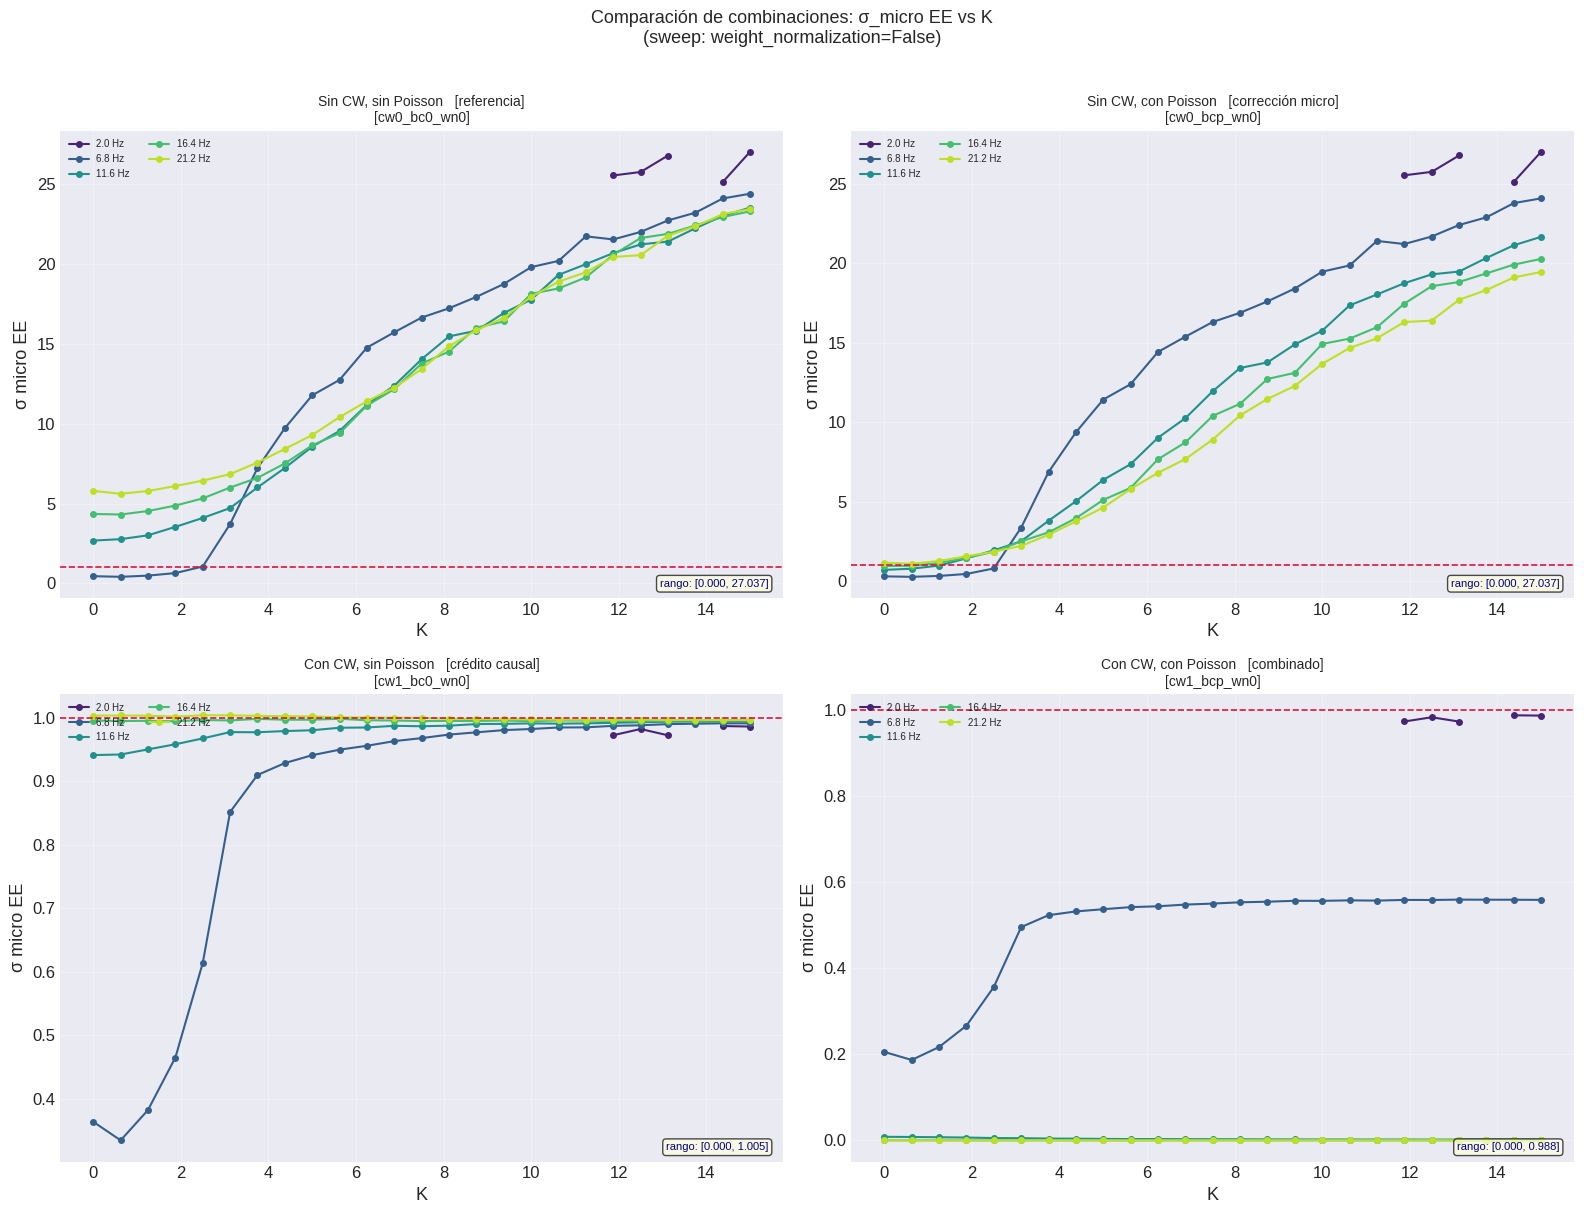

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA D — Figura comparativa: σ_micro EE para las 4 combinaciones
# ══════════════════════════════════════════════════════════════════════════════

rate_values = np.array(sorted(
    next(iter(results.values()))['df_agg']['rate_hz'].unique()
))
K_values = np.array(sorted(
    next(iter(results.values()))['df_agg']['k'].unique()
))

# Seleccionar un rate_hz de referencia (el más próximo a 10 Hz)
rate_ref = min(rate_values, key=lambda x: abs(x - 10.0))
logger.info(f"Rate de referencia para comparación: {rate_ref:.2f} Hz")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.ravel()

for ax, (tag, res) in zip(axes_flat, results.items()):
    df_a = res['df_agg']
    
    # Panel 1: σ_micro_EE vs K para todos los rates
    rate_sample = sorted(df_a['rate_hz'].unique())[::max(1, len(rate_values)//5)]
    colors_v    = plt.cm.viridis(np.linspace(0.1, 0.9, len(rate_sample)))
    
    col = 'sigma_micro_EE_mean'
    if col in df_a.columns:
        for rate, c in zip(rate_sample, colors_v):
            sub = df_a[df_a['rate_hz'] == rate].sort_values('k')
            ax.plot(sub['k'], sub[col], 'o-', color=c, ms=4, lw=1.5,
                    label=f'{rate:.1f} Hz')
    
    ax.axhline(1.0, color='crimson', ls='--', lw=1.2)
    ax.set_xlabel('K'); ax.set_ylabel('σ micro EE')
    ax.set_title(f'{res["desc"]}\n[{tag}]', fontsize=10)
    ax.legend(fontsize=7, ncol=2, loc='upper left')
    ax.grid(alpha=0.3)
    
    # Anotar rango
    vals = df_a[col].dropna()
    if len(vals):
        ax.text(0.98, 0.02,
                f'rango: [{vals.min():.3f}, {vals.max():.3f}]',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, color='navy',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Comparación de combinaciones: σ_micro EE vs K\n'
             f'(sweep: weight_normalization={"True" if WEIGHT_NORM else "False"})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(SWEEP_DIR / f'comparison_sigma_micro_wn{"1" if WEIGHT_NORM else "0"}.png',
            dpi=200, bbox_inches='tight')
plt.show()


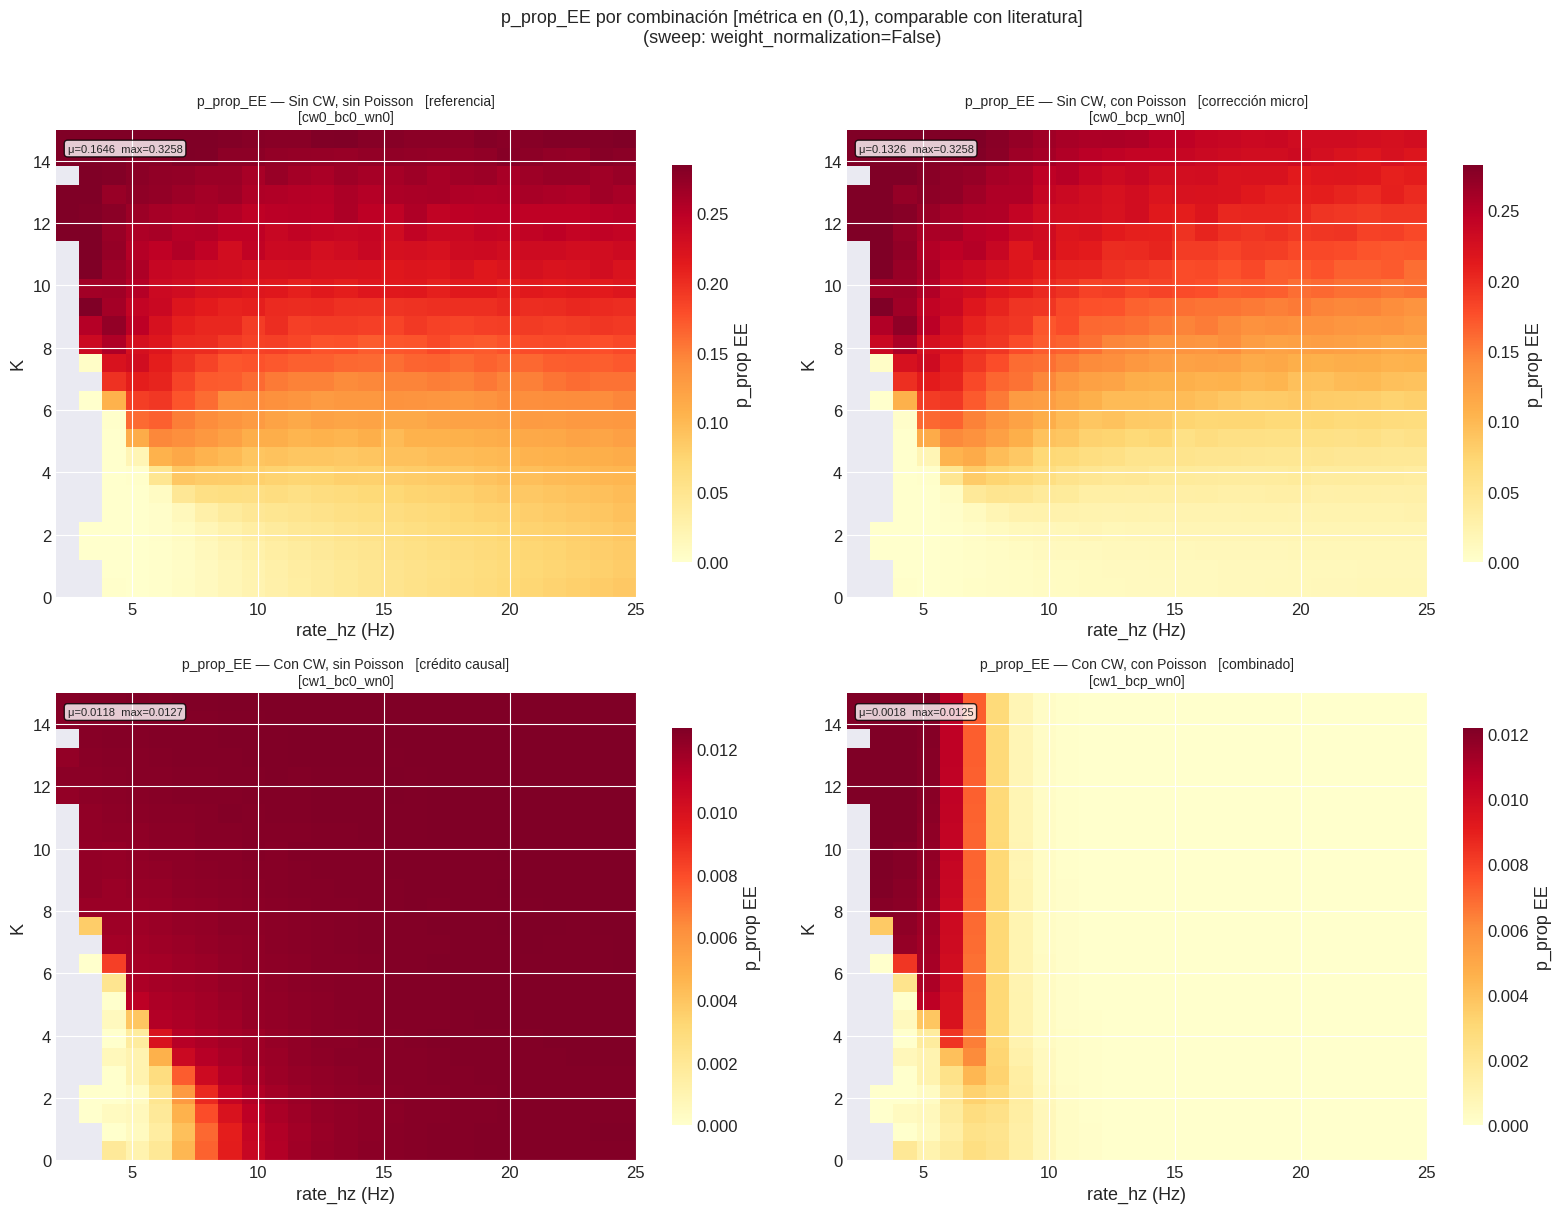

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA E — Figura comparativa: p_prop_EE (métrica normalizada [0,1])
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.ravel()

for ax, (tag, res) in zip(axes_flat, results.items()):
    df_a = res['df_agg']
    col  = 'p_prop_EE_mean'
    
    if col not in df_a.columns:
        ax.text(0.5, 0.5, 'no disponible', ha='center', va='center',
                transform=ax.transAxes)
        continue
    
    # Heatmap p_prop_EE
    try:
        pivot = df_a.pivot(index='k', columns='rate_hz', values=col)
        K_ax  = pivot.index.values
        R_ax  = pivot.columns.values
        vmax  = np.nanpercentile(pivot.values, 97)
        im    = ax.imshow(pivot.values, aspect='auto', origin='lower',
                          cmap='YlOrRd', vmin=0, vmax=vmax,
                          extent=[R_ax.min(), R_ax.max(), K_ax.min(), K_ax.max()])
        plt.colorbar(im, ax=ax, label='p_prop EE', shrink=0.85)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
    
    ax.set_xlabel('rate_hz (Hz)'); ax.set_ylabel('K')
    ax.set_title(f'p_prop_EE — {res["desc"]}\n[{tag}]', fontsize=10)
    
    vals = df_a[col].dropna()
    if len(vals):
        ax.text(0.02, 0.97,
                f'μ={vals.mean():.4f}  max={vals.max():.4f}',
                transform=ax.transAxes, ha='left', va='top',
                fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('p_prop_EE por combinación [métrica en (0,1), comparable con literatura]\n'
             f'(sweep: weight_normalization={"True" if WEIGHT_NORM else "False"})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(SWEEP_DIR / f'comparison_p_prop_wn{"1" if WEIGHT_NORM else "0"}.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA F — Test de consistencia entre combinaciones
# Verifica que CW no altera el ordenamiento relativo de las condiciones
# ══════════════════════════════════════════════════════════════════════════════

tag_base = make_run_tag(False, None, WEIGHT_NORM)
tag_cw   = make_run_tag(True,  None, WEIGHT_NORM)
tag_poi  = make_run_tag(False, 'poisson', WEIGHT_NORM)

if tag_base in results and tag_cw in results:
    df_base = results[tag_base]['df_agg']
    df_cw   = results[tag_cw]['df_agg']
    
    # Merge sobre condiciones comunes
    df_merge = df_base[['k', 'rate_hz', 'sigma_micro_EE_mean', 'p_prop_EE_mean']].merge(
        df_cw[['k', 'rate_hz', 'sigma_micro_EE_mean', 'p_prop_EE_mean']],
        on=['k', 'rate_hz'], suffixes=('_base', '_cw')
    ).dropna()
    
    if len(df_merge) > 0:
        # Test de correlación de Spearman: el ordenamiento debe conservarse
        from scipy.stats import spearmanr
        rho_sigma, p_sigma = spearmanr(df_merge['sigma_micro_EE_mean_base'],
                                        df_merge['sigma_micro_EE_mean_cw'])
        rho_p,     p_p     = spearmanr(df_merge['p_prop_EE_mean_base'],
                                        df_merge['p_prop_EE_mean_cw'])
        
        print(f"\n{'═'*60}")
        print(f"  TEST DE CONSISTENCIA: sin CW vs con CW")
        print(f"{'═'*60}")
        print(f"  Spearman σ_micro EE:  ρ = {rho_sigma:.4f}  (p = {p_sigma:.2e})")
        print(f"  Spearman p_prop_EE:   ρ = {rho_p:.4f}  (p = {p_p:.2e})")
        
        if rho_sigma > 0.95:
            print(f"  ✓ Ordenamiento prácticamente idéntico (ρ > 0.95)")
            print(f"    CW solo reescala la magnitud, no cambia el patrón")
        elif rho_sigma > 0.80:
            print(f"  ~ Ordenamiento similar (ρ > 0.80)")
            print(f"    CW introduce algunas reordenaciones locales")
        else:
            print(f"  ✗ Ordenamiento significativamente diferente (ρ < 0.80)")
            print(f"    CW cambia cualitativamente los resultados — investigar")
        
        # Factor de reescalado medio
        ratio_sigma = (df_merge['sigma_micro_EE_mean_cw'] /
                       df_merge['sigma_micro_EE_mean_base'].replace(0, np.nan)).dropna()
        ratio_p     = (df_merge['p_prop_EE_mean_cw'] /
                       df_merge['p_prop_EE_mean_base'].replace(0, np.nan)).dropna()
        
        print(f"\n  Factor de reescalado (CW/base):")
        print(f"    σ_micro EE: {ratio_sigma.mean():.4f} ± {ratio_sigma.std():.4f}")
        print(f"    p_prop_EE:  {ratio_p.mean():.4f} ± {ratio_p.std():.4f}")
        print(f"    (homogéneo → CW es una reescala uniforme)")
        print(f"    CV(ratio σ): {ratio_sigma.std()/ratio_sigma.mean():.3f}")
        print(f"    CV(ratio p): {ratio_p.std()/ratio_p.mean():.3f}")
        print(f"═"*60)

if tag_base in results and tag_poi in results:
    df_base = results[tag_base]['df_agg']
    df_poi  = results[tag_poi]['df_agg']
    
    df_merge2 = df_base[['k', 'rate_hz', 'p_prop_EE_mean']].merge(
        df_poi[['k', 'rate_hz', 'p_prop_EE_mean']],
        on=['k', 'rate_hz'], suffixes=('_base', '_poi')
    ).dropna()
    
    if len(df_merge2) > 0:
        corr_poi = df_merge2['p_prop_EE_mean_base'].corr(
            df_merge2['p_prop_EE_mean_poi'])
        delta_poi = (df_merge2['p_prop_EE_mean_base'] -
                     df_merge2['p_prop_EE_mean_poi'])
        
        print(f"\n  TEST DE CONSISTENCIA: sin Poisson vs con Poisson")
        print(f"  Pearson p_prop_EE: r = {corr_poi:.4f}")
        print(f"  Reducción media por corrección Poisson: "
              f"{delta_poi.mean():.5f} ± {delta_poi.std():.5f}")
        print(f"  Reducción relativa: {(delta_poi/df_merge2['p_prop_EE_mean_base']).mean()*100:.2f}%")


════════════════════════════════════════════════════════════
  TEST DE CONSISTENCIA: sin CW vs con CW
════════════════════════════════════════════════════════════
  Spearman σ_micro EE:  ρ = 0.1059  (p = 9.66e-03)
  Spearman p_prop_EE:   ρ = 0.5549  (p = 1.97e-49)
  ✗ Ordenamiento significativamente diferente (ρ < 0.80)
    CW cambia cualitativamente los resultados — investigar

  Factor de reescalado (CW/base):
    σ_micro EE: 0.1346 ± 0.1835
    p_prop_EE:  0.1369 ± 0.1827
    (homogéneo → CW es una reescala uniforme)
    CV(ratio σ): 1.363
    CV(ratio p): 1.334
════════════════════════════════════════════════════════════

  TEST DE CONSISTENCIA: sin Poisson vs con Poisson
  Pearson p_prop_EE: r = 0.9717
  Reducción media por corrección Poisson: 0.03203 ± 0.02181
  Reducción relativa: 28.05%


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 6 — Comparación de Estimadores de σ vs K
# ══════════════════════════════════════════════════════════════════════════════

rate_sample = sorted(df_agg['rate_hz'].unique())
rate_sample = rate_sample[::max(1, len(rate_sample) // 6)]
colors_v    = plt.cm.plasma(np.linspace(0.1, 0.9, len(rate_sample)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [
    (df_agg,    'sigma_global_mean',      'σ global — Beggs & Plenz',       'σ'),
    (df_agg,    'sigma_global_corr_mean', 'σ global corr. — W&P 2018',      'σ (corr.)'),
    (df_agg,    'sigma_micro_EE_mean',    'σ micro E→E — tiempo continuo',  'σ micro EE'),
]

for ax, (df_src, col, title, ylabel) in zip(axes, panels):
    if col not in df_src.columns:
        ax.text(0.5, 0.5, 'no disponible', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        continue
    for rate, c in zip(rate_sample, colors_v):
        sub = df_src[df_src['rate_hz'] == rate].sort_values('k')
        err_col = col.replace('_mean', '_std')
        ax.plot(sub['k'], sub[col], 'o-', color=c, label=f'{rate:.0f} Hz',
                ms=5, lw=1.8)
        if err_col in sub.columns:
            ax.fill_between(sub['k'],
                            sub[col] - sub[err_col] / np.sqrt(n_trials),
                            sub[col] + sub[err_col] / np.sqrt(n_trials),
                            color=c, alpha=0.15)
    ax.axhline(1.0, color='crimson', ls='--', lw=1.2, zorder=5)
    ax.set_xlabel('K (acoplamiento)'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Estimadores de branching ratio vs K', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(SWEEP_DIR / 'sigma_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


NameError: name 'df_agg' is not defined

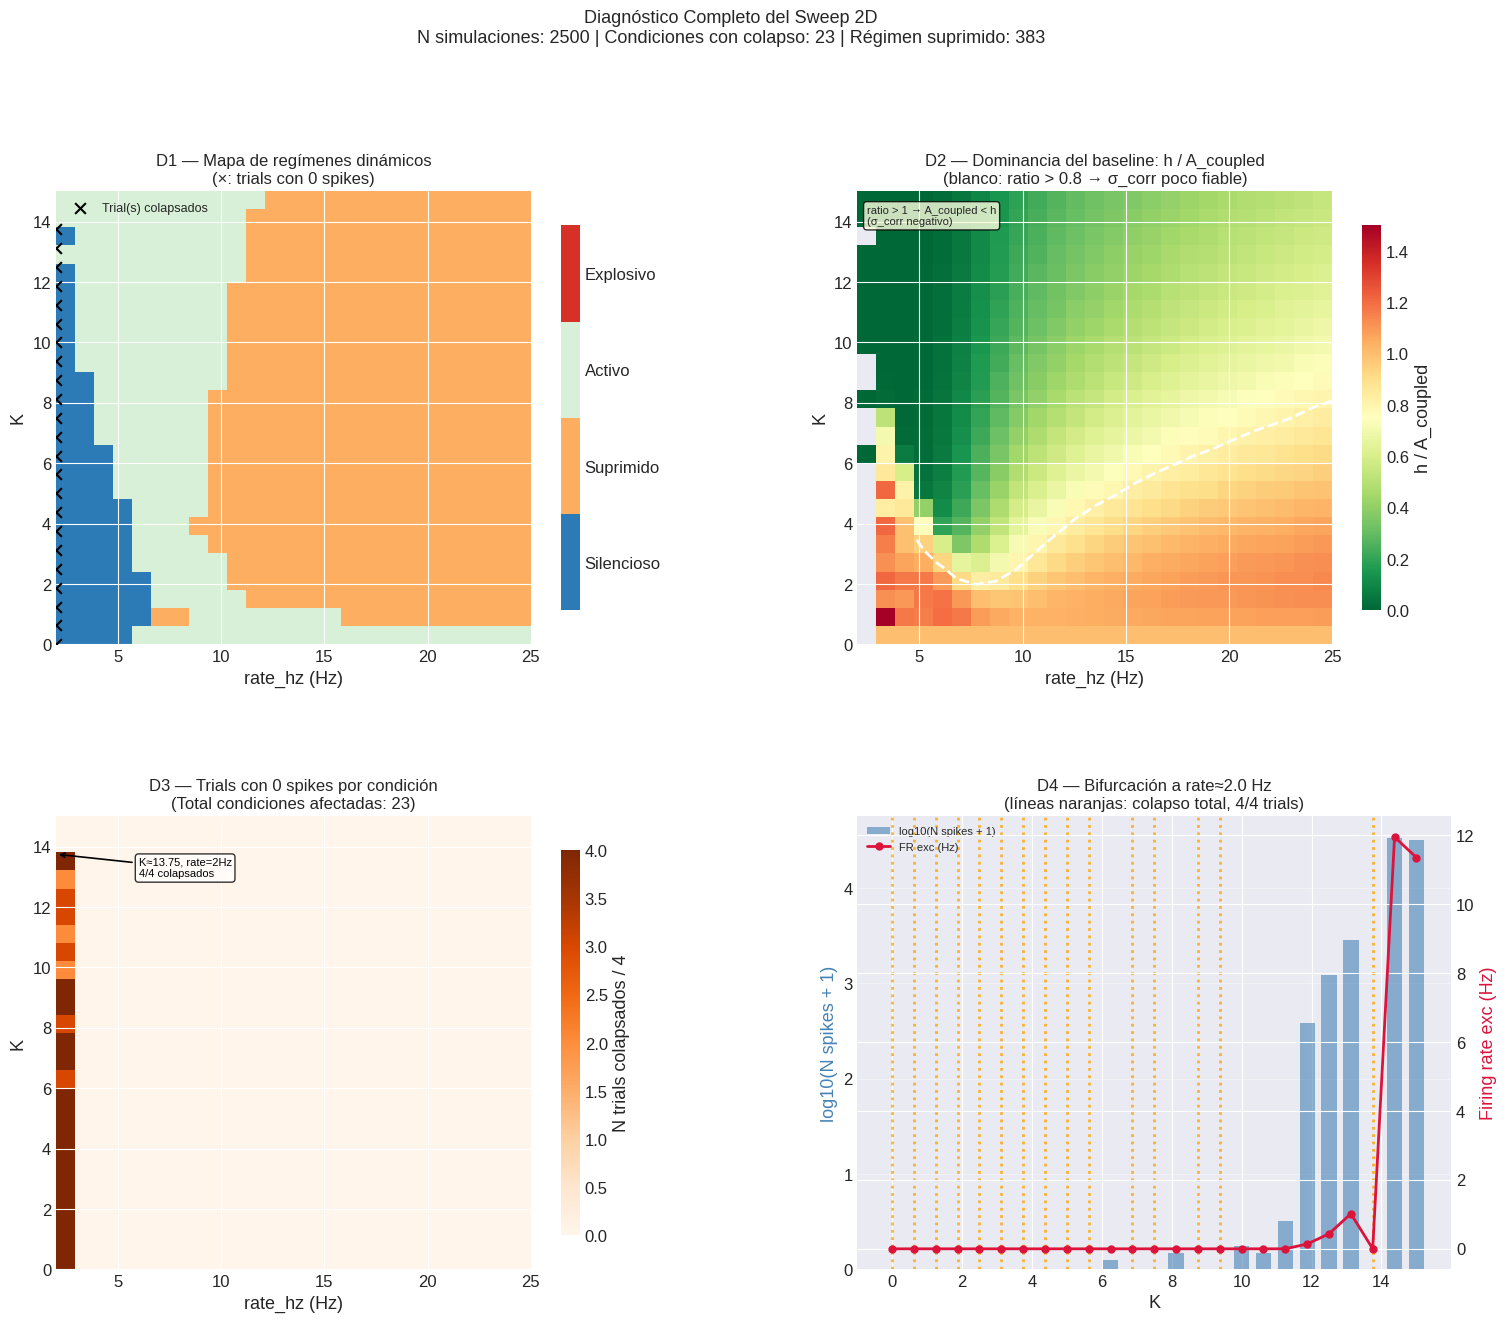

INFO     | __main__:<module>:249 - Diagnóstico guardado en: diagnostico_regimenes.csv
INFO     | __main__:<module>:250 - df_diag shape: (625, 15) | columnas: ['k', 'rate_hz', 'n_spikes_exc_mean', 'n_spikes_exc_std', 'n_spikes_exc_min', 'sigma_micro_EE_mean', 'sigma_global_corr_m', 'A_mean_coupled', 'firing_rate_exc', 'n_collapsed_trials', 'A_baseline', 'ratio_h_A', 'regime', 'has_collapsed_trials', 'sigma_corr_unreliable']



═════════════════════════════════════════════════════════════════
  RESUMEN DE DIAGNÓSTICO
═════════════════════════════════════════════════════════════════
  Suprimido            :  383 condiciones (61.3%)
  Activo               :  183 condiciones (29.3%)
  Silencioso           :   59 condiciones (9.4%)

  Condiciones con ≥1 trial colapsado : 23
  Condiciones con σ_corr poco fiable  : 236 (h/A_coupled > 0.8 o régimen extremo)

  Rangos de h (baseline k=0) por rate:
    rate≈ 2Hz (actual=2.00):  h=0.00  A_coupled=[0.00, 9.56]
    rate≈ 7Hz (actual=6.79):  h=1.12  A_coupled=[0.96, 22.23]
    rate≈12Hz (actual=11.58):  h=6.69  A_coupled=[6.46, 25.05]
    rate≈16Hz (actual=16.38):  h=10.81  A_coupled=[10.06, 27.67]
    rate≈21Hz (actual=21.17):  h=14.37  A_coupled=[12.98, 29.87]

  Interpretación de σ_global_corr negativo:
    451/625 condiciones con σ_corr < 0
    Causa: A_coupled(t+1) < h en promedio → inhibición suprime
    la actividad por debajo del nivel Poisson puro.
    Solución:

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA C — Tabla comparativa de métricas clave
# ══════════════════════════════════════════════════════════════════════════════

# Métricas a comparar en el régimen Activo (FR_exc > 0.5 Hz y < 40 Hz)
METRICS_TO_COMPARE = [
    ('sigma_micro_EE',   'σ micro EE'),
    ('sigma_global',     'σ global'),
    ('sigma_global_corr','σ global corr.'),
    ('p_prop_EE',        'p_prop EE'),
    ('p_prop_Eall',      'p_prop Eall'),
]

print(f"\n{'═'*90}")
print(f"  TABLA COMPARATIVA — régimen Activo (FR_exc ∈ [0.5, 40] Hz)")
print(f"{'═'*90}")
print(f"  {'Tag':<14} {'Descripción':<35} {'Métrica':<20} {'Media':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print(f"  {'─'*90}")

for tag, res in results.items():
    df_r = res['df_raw']
    # Filtrar régimen Activo
    mask_active = (df_r['firing_rate_exc'] >= 0.5) & (df_r['firing_rate_exc'] <= 40.0)
    df_active   = df_r[mask_active]
    
    if len(df_active) == 0:
        print(f"  {tag:<14} {res['desc']:<35} {'(sin datos activos)'}")
        continue
    
    first = True
    for col, label in METRICS_TO_COMPARE:
        if col not in df_active.columns:
            continue
        vals = df_active[col].dropna()
        if len(vals) == 0:
            continue
        tag_str  = tag  if first else ''
        desc_str = res['desc'] if first else ''
        print(f"  {tag_str:<14} {desc_str:<35} {label:<20} "
              f"{vals.mean():>8.4f} {vals.std():>8.4f} "
              f"{vals.min():>8.4f} {vals.max():>8.4f}")
        first = False
    print(f"  {'─'*90}")

print(f"\n  N simulaciones en régimen Activo por combinación:")
for tag, res in results.items():
    df_r    = res['df_raw']
    mask    = (df_r['firing_rate_exc'] >= 0.5) & (df_r['firing_rate_exc'] <= 40.0)
    n_act   = mask.sum()
    n_total = len(df_r)
    print(f"    {tag:<14}: {n_act:>5}/{n_total} ({n_act/n_total*100:.1f}%)")


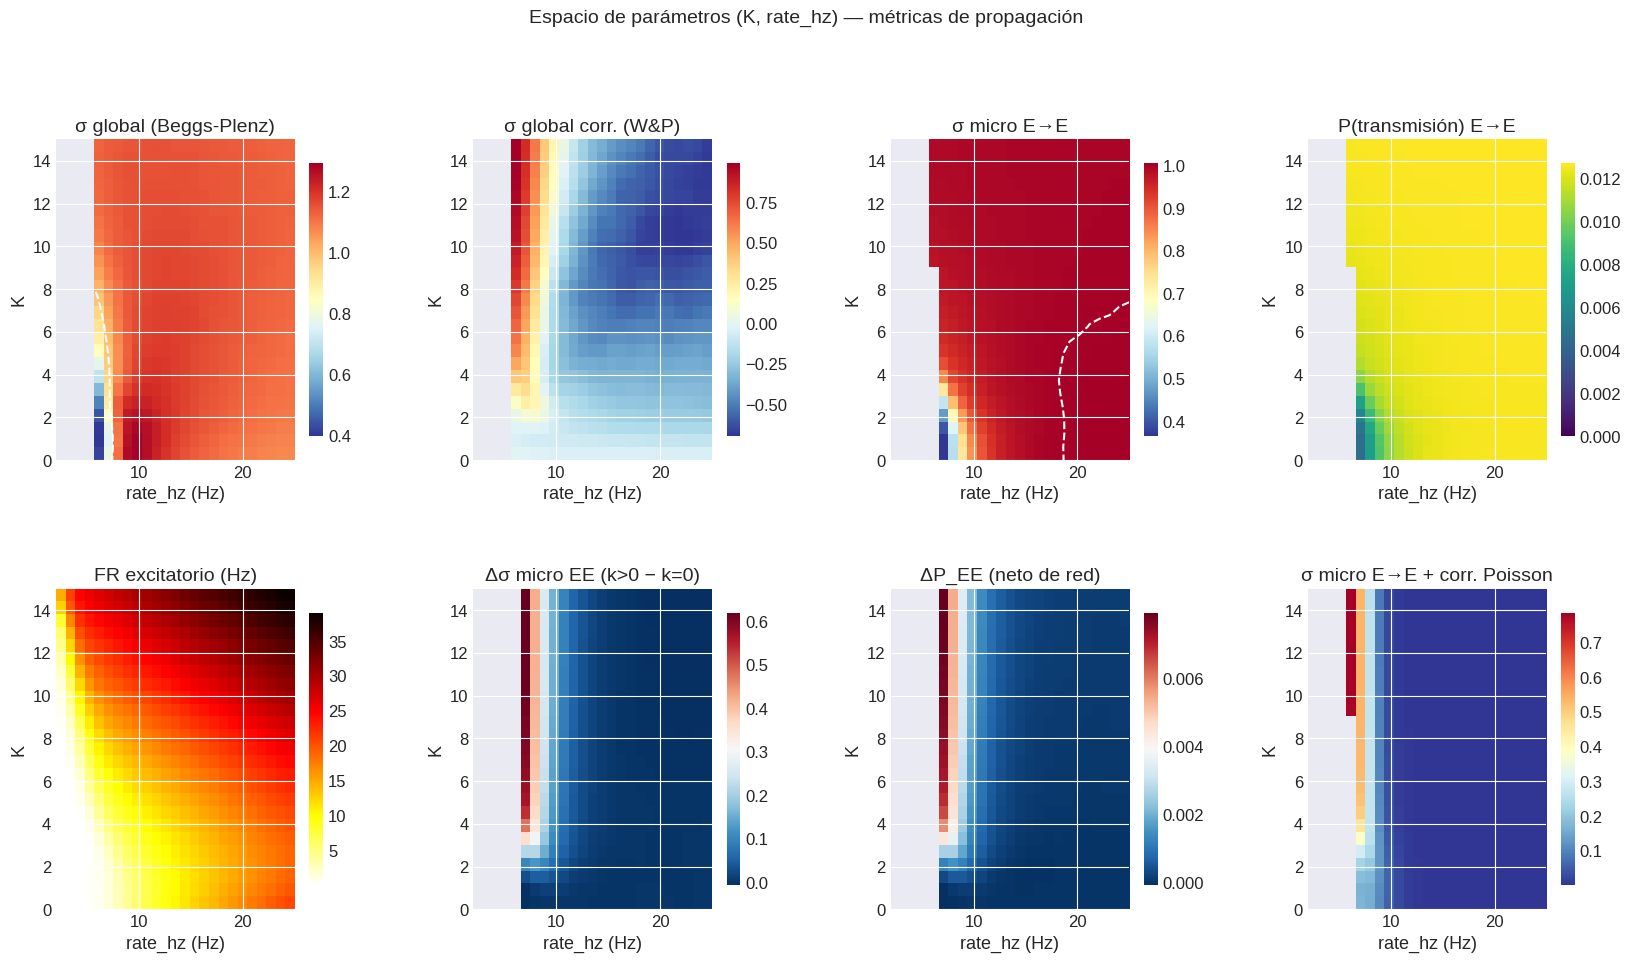

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 7 — Heatmaps 2D: Espacio (K, rate_hz)
# ══════════════════════════════════════════════════════════════════════════════

def heatmap_metric(df, metric_col, title, ax, cmap='viridis', vmin=None, vmax=None,
                   smooth_sigma=0.8):
    pivot = df.pivot(index='k', columns='rate_hz', values=metric_col)
    K_ax  = pivot.index.values
    R_ax  = pivot.columns.values
    data  = pivot.values.astype(float)
    if smooth_sigma:
        # Suavizado gaussiano leve para presentación (no altera los datos originales)
        data = gaussian_filter(data, sigma=smooth_sigma)
    im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap,
                   vmin=vmin, vmax=vmax,
                   extent=[R_ax.min(), R_ax.max(), K_ax.min(), K_ax.max()])
    ax.set_xlabel('rate_hz (Hz)'); ax.set_ylabel('K')
    ax.set_title(title)
    return im

fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.4)

panels_hm = [
    (df_agg,   'sigma_global_mean',      'σ global (Beggs-Plenz)',      'RdYlBu_r', None, None),
    (df_agg,   'sigma_global_corr_mean', 'σ global corr. (W&P)',        'RdYlBu_r', None, None),
    (df_agg,   'sigma_micro_EE_mean',    'σ micro E→E',                  'RdYlBu_r', None, None),
    (df_agg,   'p_prop_EE_mean',         'P(transmisión) E→E',          'viridis',  0,    None),
    (df_agg,   'firing_rate_exc_mean',   'FR excitatorio (Hz)',          'hot_r',    None, None),
    (df_agg,   'delta_sigma_micro_EE',   'Δσ micro EE (k>0 − k=0)',      'RdBu_r',   None, None),
    (df_agg,   'delta_p_prop_EE',        'ΔP_EE (neto de red)',          'RdBu_r',   None, None),
    (df_agg_p, 'sigma_micro_EE_mean',    'σ micro E→E + corr. Poisson',  'RdYlBu_r', None, None),
]

axes_flat = [fig.add_subplot(gs[i // 4, i % 4]) for i in range(8)]

for ax, (df_src, col, title, cmap, vmin, vmax) in zip(axes_flat, panels_hm):
    if col not in df_src.columns:
        ax.text(0.5, 0.5, f'{col}\nnot available', ha='center', va='center',
                transform=ax.transAxes, fontsize=9)
        ax.set_title(title, fontsize=10)
        continue
    im = heatmap_metric(df_src, col, title, ax, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.85)
    # Contorno σ=1
    if 'sigma' in col and 'delta' not in col:
        try:
            pivot = df_src.pivot(index='k', columns='rate_hz', values=col)
            K_ax  = pivot.index.values
            R_ax  = pivot.columns.values
            ax.contour(R_ax, K_ax, gaussian_filter(pivot.values, 0.8),
                       levels=[1.0], colors='white', linewidths=1.5, linestyles='--')
        except Exception:
            pass

plt.suptitle('Espacio de parámetros (K, rate_hz) — métricas de propagación',
             fontsize=14, y=1.01)
plt.savefig(SWEEP_DIR / 'heatmaps_2d.png', dpi=200, bbox_inches='tight')
plt.show()


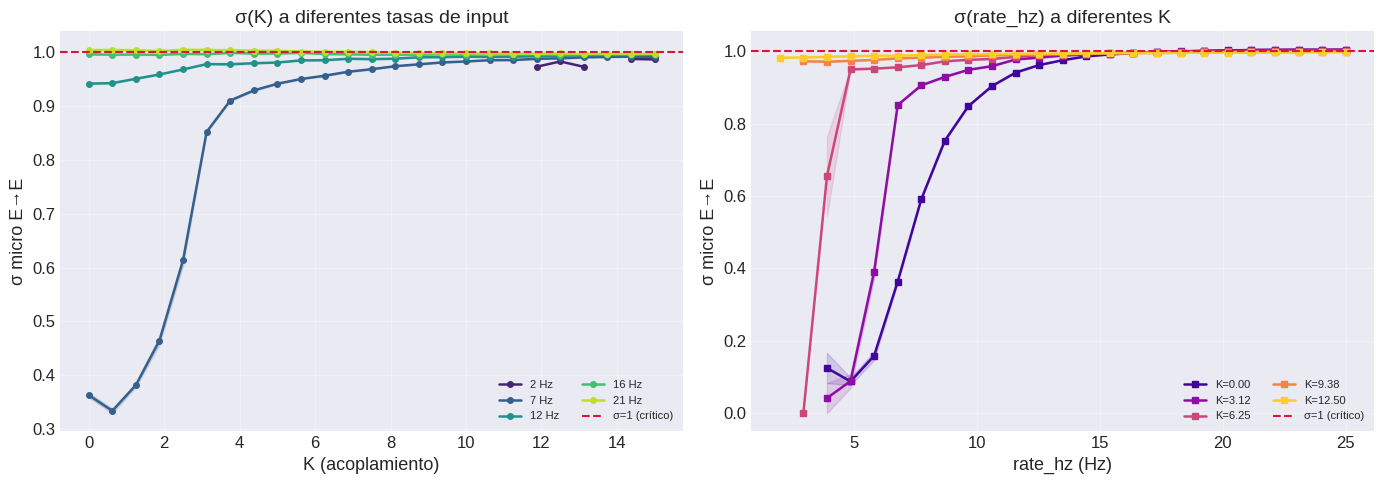

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 8 — Perfiles de σ: slices a rate_hz fijo y K fijo
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Slice a rate_hz fijo: σ(K) ────────────────────────────────────────────────
rates_plot = sorted(df_agg['rate_hz'].unique())
rates_plot = rates_plot[::max(1, len(rates_plot) // 5)]
c_rates    = plt.cm.viridis(np.linspace(0.1, 0.9, len(rates_plot)))

for rate, c in zip(rates_plot, c_rates):
    sub = df_agg[df_agg['rate_hz'] == rate].sort_values('k')
    axes[0].plot(sub['k'], sub['sigma_micro_EE_mean'], 'o-', color=c,
                 label=f'{rate:.0f} Hz', ms=4, lw=1.8)
    axes[0].fill_between(
        sub['k'],
        sub['sigma_micro_EE_mean'] - sub['sigma_micro_EE_std'] / np.sqrt(n_trials),
        sub['sigma_micro_EE_mean'] + sub['sigma_micro_EE_std'] / np.sqrt(n_trials),
        color=c, alpha=0.15)

axes[0].axhline(1.0, color='crimson', ls='--', lw=1.5, label='σ=1 (crítico)')
axes[0].set_xlabel('K (acoplamiento)'); axes[0].set_ylabel('σ micro E→E')
axes[0].set_title('σ(K) a diferentes tasas de input')
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3)

# ── Slice a K fijo: σ(rate_hz) ───────────────────────────────────────────────
K_vals_plot = sorted(df_agg['k'].unique())
K_vals_plot = K_vals_plot[::max(1, len(K_vals_plot) // 5)]
c_k         = plt.cm.plasma(np.linspace(0.1, 0.9, len(K_vals_plot)))

for k_val, c in zip(K_vals_plot, c_k):
    sub = df_agg[df_agg['k'] == k_val].sort_values('rate_hz')
    axes[1].plot(sub['rate_hz'], sub['sigma_micro_EE_mean'], 's-', color=c,
                 label=f'K={k_val:.2f}', ms=4, lw=1.8)
    axes[1].fill_between(
        sub['rate_hz'],
        sub['sigma_micro_EE_mean'] - sub['sigma_micro_EE_std'] / np.sqrt(n_trials),
        sub['sigma_micro_EE_mean'] + sub['sigma_micro_EE_std'] / np.sqrt(n_trials),
        color=c, alpha=0.15)

axes[1].axhline(1.0, color='crimson', ls='--', lw=1.5, label='σ=1 (crítico)')
axes[1].set_xlabel('rate_hz (Hz)'); axes[1].set_ylabel('σ micro E→E')
axes[1].set_title('σ(rate_hz) a diferentes K')
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SWEEP_DIR / 'sigma_profiles.png', dpi=200, bbox_inches='tight')
plt.show()


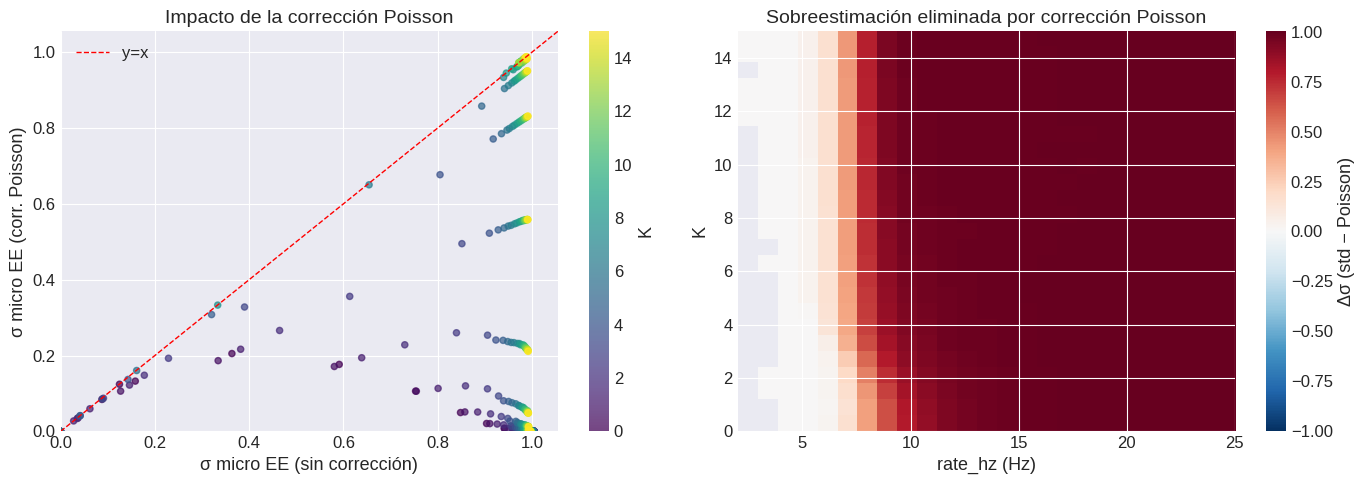

INFO     | __main__:<module>:47 - Corrección Poisson — efecto sobre σ micro EE:
INFO     | __main__:<module>:48 -   Media: 0.7933  Std: 0.3596
INFO     | __main__:<module>:49 -   Min:   0.0000  Max: 1.0046


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 9 — Comparación: Sin corrección vs Corrección Poisson
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Merge para comparación directa
df_cmp = df_agg[['k', 'rate_hz', 'sigma_micro_EE_mean', 'p_prop_EE_mean']].merge(
    df_agg_p[['k', 'rate_hz', 'sigma_micro_EE_mean', 'p_prop_EE_mean']],
    on=['k', 'rate_hz'], suffixes=('_std', '_poi')
)

# ── Scatter: std vs poisson σ ─────────────────────────────────────────────────
sc = axes[0].scatter(df_cmp['sigma_micro_EE_mean_std'],
                     df_cmp['sigma_micro_EE_mean_poi'],
                     c=df_cmp['k'], cmap='viridis', s=20, alpha=0.7)
lim = [min(df_cmp['sigma_micro_EE_mean_std'].min(),
           df_cmp['sigma_micro_EE_mean_poi'].min()) * 0.95,
       max(df_cmp['sigma_micro_EE_mean_std'].max(),
           df_cmp['sigma_micro_EE_mean_poi'].max()) * 1.05]
axes[0].plot(lim, lim, 'r--', lw=1, label='y=x')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
plt.colorbar(sc, ax=axes[0], label='K')
axes[0].set_xlabel('σ micro EE (sin corrección)')
axes[0].set_ylabel('σ micro EE (corr. Poisson)')
axes[0].set_title('Impacto de la corrección Poisson'); axes[0].legend()

# ── Diferencia absoluta: (std - poi) por (K, rate) ───────────────────────────
df_cmp['delta_correction'] = df_cmp['sigma_micro_EE_mean_std'] - df_cmp['sigma_micro_EE_mean_poi']
pivot_diff = df_cmp.pivot(index='k', columns='rate_hz', values='delta_correction')
K_ax  = pivot_diff.index.values
R_ax  = pivot_diff.columns.values
vmax  = np.nanpercentile(np.abs(pivot_diff.values), 95)
im    = axes[1].imshow(pivot_diff.values, aspect='auto', origin='lower',
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       extent=[R_ax.min(), R_ax.max(), K_ax.min(), K_ax.max()])
plt.colorbar(im, ax=axes[1], label='Δσ (std − Poisson)')
axes[1].set_xlabel('rate_hz (Hz)'); axes[1].set_ylabel('K')
axes[1].set_title('Sobreestimación eliminada por corrección Poisson')

plt.tight_layout()
plt.savefig(SWEEP_DIR / 'poisson_correction_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadística resumen de la corrección
delta = df_cmp['delta_correction']
logger.info(f"Corrección Poisson — efecto sobre σ micro EE:")
logger.info(f"  Media: {delta.mean():.4f}  Std: {delta.std():.4f}")
logger.info(f"  Min:   {delta.min():.4f}  Max: {delta.max():.4f}")


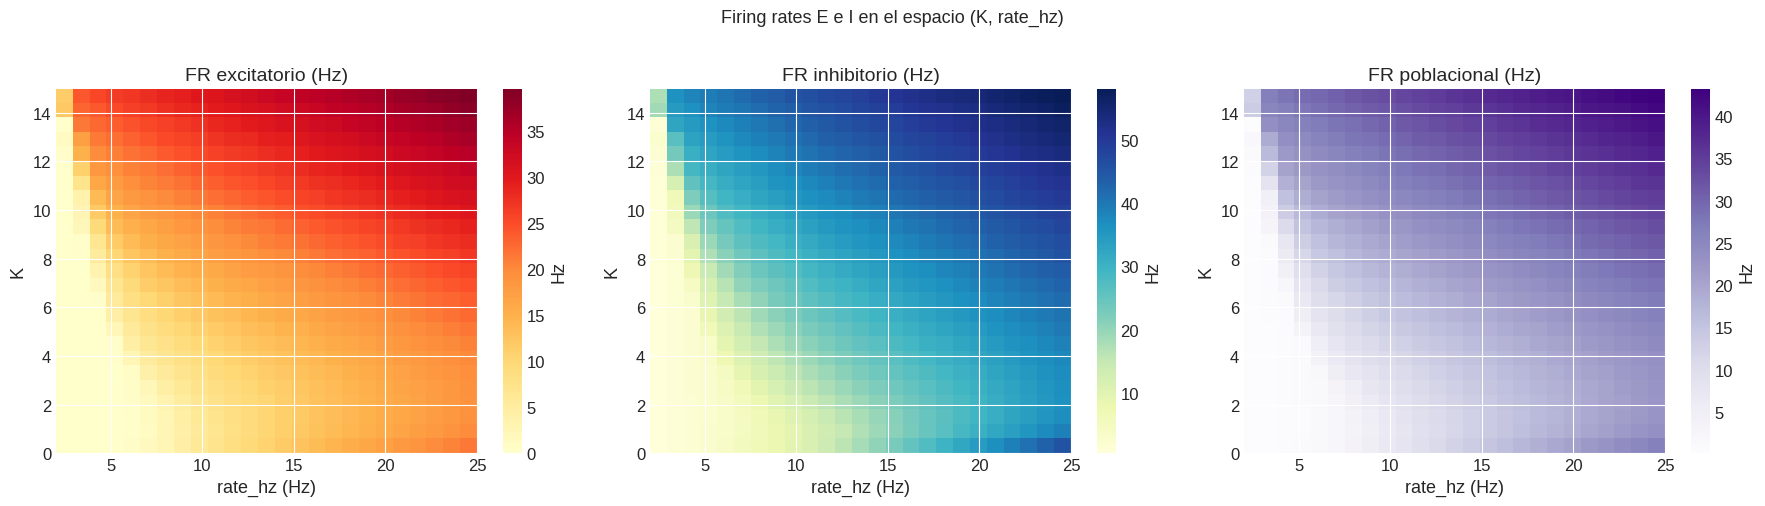

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 10 — Firing Rates E vs I en el Espacio de Parámetros
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hm_panels = [
    ('firing_rate_exc_mean', 'FR excitatorio (Hz)',    'YlOrRd'),
    ('firing_rate_inh_mean', 'FR inhibitorio (Hz)',    'YlGnBu'),
    ('firing_rate_all_mean', 'FR poblacional (Hz)',    'Purples'),
]
for ax, (col, title, cmap) in zip(axes, hm_panels):
    if col not in df_agg.columns:
        continue
    pivot = df_agg.pivot(index='k', columns='rate_hz', values=col)
    K_ax  = pivot.index.values; R_ax = pivot.columns.values
    im    = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap=cmap,
                      extent=[R_ax.min(), R_ax.max(), K_ax.min(), K_ax.max()])
    plt.colorbar(im, ax=ax, label='Hz')
    ax.set_xlabel('rate_hz (Hz)'); ax.set_ylabel('K')
    ax.set_title(title)

plt.suptitle('Firing rates E e I en el espacio (K, rate_hz)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(SWEEP_DIR / 'firing_rates_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


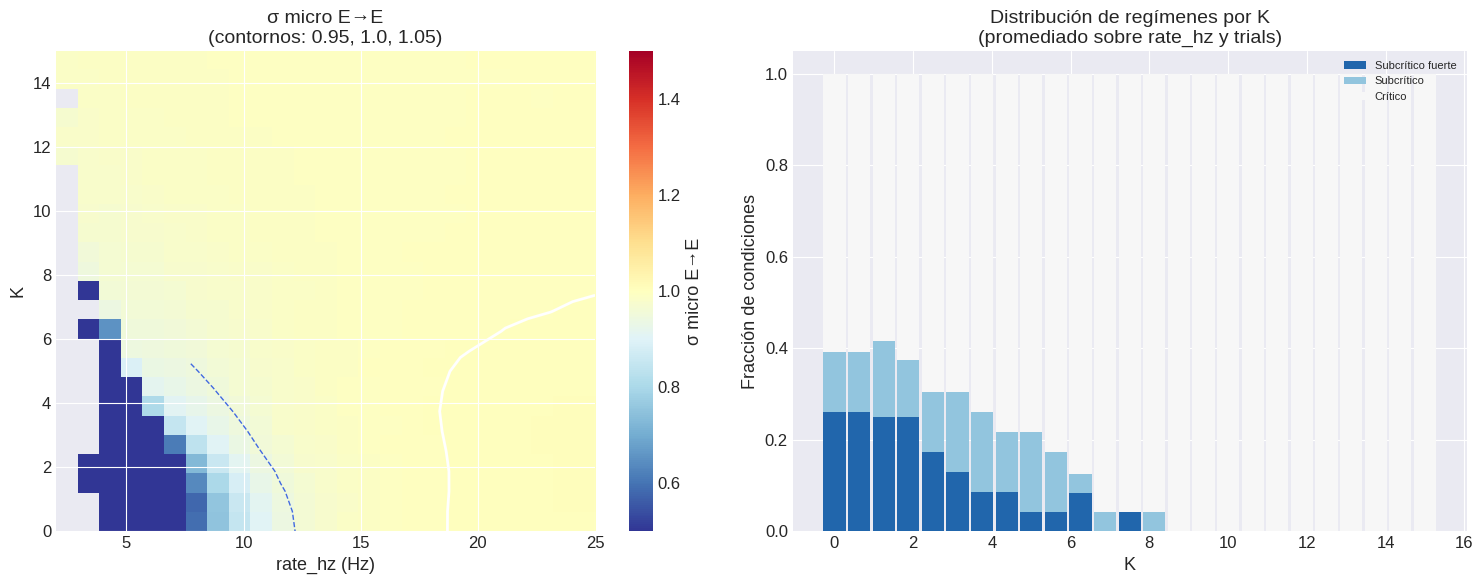

INFO     | __main__:<module>:64 -   rate=2.0Hz → K_critico ≈ [11.875 12.5   13.125 14.375 15.   ]
INFO     | __main__:<module>:64 -   rate=7.8Hz → K_critico ≈ [ 5.625  6.25   6.875  7.5    8.125  8.75   9.375 10.    10.625 11.25
 11.875 12.5   13.125 13.75  14.375 15.   ]
INFO     | __main__:<module>:64 -   rate=13.5Hz → K_critico ≈ [ 0.     0.625  1.25   1.875  2.5    3.125  3.75   4.375  5.     5.625
  6.25   6.875  7.5    8.125  8.75   9.375 10.    10.625 11.25  11.875
 12.5   13.125 13.75  14.375 15.   ]
INFO     | __main__:<module>:64 -   rate=19.2Hz → K_critico ≈ [ 0.     0.625  1.25   1.875  2.5    3.125  3.75   4.375  5.     5.625
  6.25   6.875  7.5    8.125  8.75   9.375 10.    10.625 11.25  11.875
 12.5   13.125 13.75  14.375 15.   ]
INFO     | __main__:<module>:64 -   rate=25.0Hz → K_critico ≈ [ 0.     0.625  1.25   1.875  2.5    3.125  3.75   4.375  5.     5.625
  6.25   6.875  7.5    8.125  8.75   9.375 10.    10.625 11.25  11.875
 12.5   13.125 13.75  14.375 15.   ]


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 11 — Mapa de Criticidad (σ ≈ 1)
# Identifica la región del espacio de parámetros donde la red opera
# cerca del régimen crítico
# ══════════════════════════════════════════════════════════════════════════════

# Clasificar regímenes por σ micro EE
col = 'sigma_micro_EE_mean'
df_crit = df_agg[['k', 'rate_hz', col]].copy()
df_crit['regime'] = pd.cut(
    df_crit[col],
    bins=[-np.inf, 0.8, 0.95, 1.05, 1.2, np.inf],
    labels=['Subcrítico fuerte', 'Subcrítico', 'Crítico', 'Supercrítico', 'Supercrítico fuerte']
)

pivot_sig = df_crit.pivot(index='k', columns='rate_hz', values=col)
K_ax  = pivot_sig.index.values
R_ax  = pivot_sig.columns.values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Mapa continuo de σ con contorno σ=1 ──────────────────────────────────────
im = axes[0].imshow(pivot_sig.values, aspect='auto', origin='lower',
                    cmap='RdYlBu_r', vmin=0.5, vmax=1.5,
                    extent=[R_ax.min(), R_ax.max(), K_ax.min(), K_ax.max()])
plt.colorbar(im, ax=axes[0], label='σ micro E→E')
axes[0].contour(R_ax, K_ax, gaussian_filter(pivot_sig.values, 1.0),
                levels=[0.95, 1.0, 1.05],
                colors=['royalblue', 'white', 'firebrick'],
                linewidths=[1, 2, 1], linestyles=['--', '-', '--'])
axes[0].set_xlabel('rate_hz (Hz)'); axes[0].set_ylabel('K')
axes[0].set_title('σ micro E→E\n(contornos: 0.95, 1.0, 1.05)')

# ── Fracción de simulaciones en cada régimen por K ───────────────────────────
regime_counts = df_crit.groupby(['k', 'regime'], observed=True).size().unstack(fill_value=0)
regime_counts = regime_counts.div(regime_counts.sum(axis=1), axis=0)
regime_colors = {
    'Subcrítico fuerte': '#2166ac',
    'Subcrítico':        '#92c5de',
    'Crítico':           '#f7f7f7',
    'Supercrítico':      '#f4a582',
    'Supercrítico fuerte': '#d6604d',
}
bottom = np.zeros(len(regime_counts))
for regime in ['Subcrítico fuerte', 'Subcrítico', 'Crítico', 'Supercrítico', 'Supercrítico fuerte']:
    if regime not in regime_counts.columns:
        continue
    vals = regime_counts[regime].values
    axes[1].bar(regime_counts.index, vals, bottom=bottom,
                color=regime_colors[regime], label=regime, width=np.diff(K_ax).min()*0.9)
    bottom += vals
axes[1].set_xlabel('K'); axes[1].set_ylabel('Fracción de condiciones')
axes[1].set_title('Distribución de regímenes por K\n(promediado sobre rate_hz y trials)')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(SWEEP_DIR / 'criticality_map.png', dpi=200, bbox_inches='tight')
plt.show()

# Tabla resumen: K donde σ cruza 1
for rate in sorted(df_agg['rate_hz'].unique())[::max(1,len(rate_values)//4)]:
    sub = df_agg[df_agg['rate_hz']==rate].sort_values('k')
    crossing = sub[np.abs(sub['sigma_micro_EE_mean'] - 1.0) < 0.05]['k'].values
    logger.info(f"  rate={rate:.1f}Hz → K_critico ≈ {crossing if len(crossing) else 'no cruzado'}")


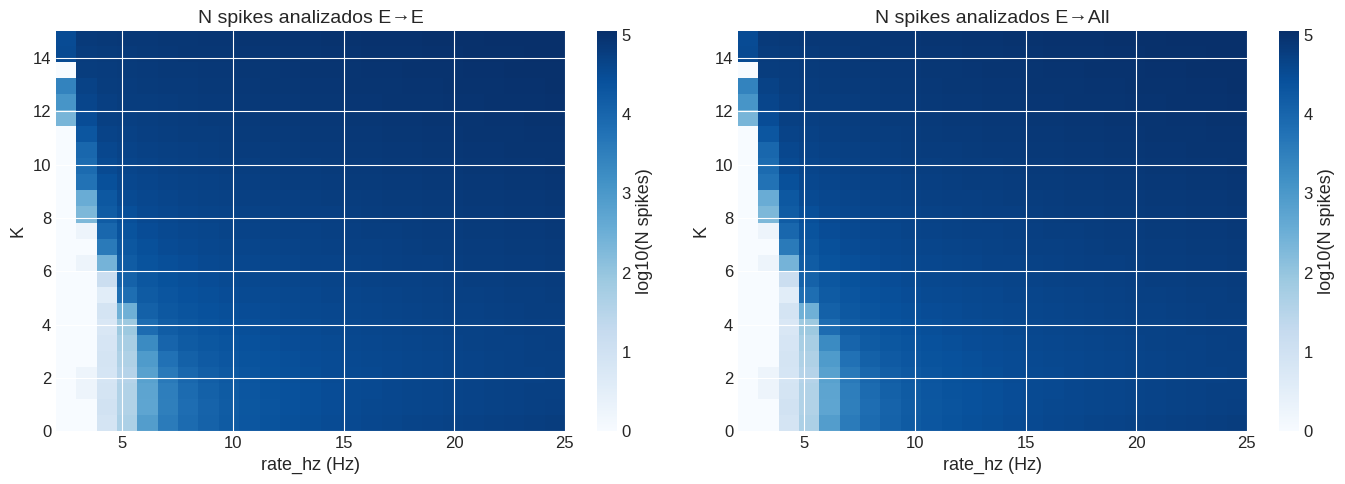

WARNING  | __main__:<module>:31 - 203 sims con < 50 spikes analizados E→E (estimación puede ser ruidosa)
INFO     | __main__:<module>:33 -      k   rate_hz  n_spikes_analyzed_EE
0  0.0  2.000000                     0
1  0.0  2.000000                     0
2  0.0  2.000000                     0
3  0.0  2.000000                     0
4  0.0  2.958333                     0


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 12 — Diagnóstico: n_spikes_analyzed y cobertura del análisis
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'n_spikes_analyzed_EE',   'N spikes analizados E→E'),
    (axes[1], 'n_spikes_analyzed_Eall', 'N spikes analizados E→All'),
]:
    if col not in df_raw.columns:
        ax.text(0.5, 0.5, 'no disponible', ha='center', va='center',
                transform=ax.transAxes); continue
    df_mean_n = df_raw.groupby(['k', 'rate_hz'])[col].mean().reset_index()
    pivot = df_mean_n.pivot(index='k', columns='rate_hz', values=col)
    K_ax  = pivot.index.values; R_ax = pivot.columns.values
    im = ax.imshow(np.log10(pivot.values + 1), aspect='auto', origin='lower',
                   cmap='Blues',
                   extent=[R_ax.min(), R_ax.max(), K_ax.min(), K_ax.max()])
    plt.colorbar(im, ax=ax, label='log10(N spikes)')
    ax.set_xlabel('rate_hz (Hz)'); ax.set_ylabel('K')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(SWEEP_DIR / 'n_spikes_coverage.png', dpi=200, bbox_inches='tight')
plt.show()

# Alertar si hay condiciones con pocos spikes (posible estimación ruidosa)
low_coverage = df_raw[df_raw['n_spikes_analyzed_EE'] < 50]
if len(low_coverage) > 0:
    logger.warning(f"{len(low_coverage)} sims con < 50 spikes analizados E→E "
                   f"(estimación puede ser ruidosa)")
    logger.info(df_low := low_coverage[['k','rate_hz','n_spikes_analyzed_EE']].head(5))
else:
    logger.info("Cobertura de spikes correcta en todas las condiciones.")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 13 — Guardado Final y Resumen
# ══════════════════════════════════════════════════════════════════════════════

# Exportar tabla combinada std + poisson
df_combined = df_agg.merge(
    df_agg_p[['k', 'rate_hz', 'sigma_micro_EE_mean', 'p_prop_EE_mean']],
    on=['k', 'rate_hz'], suffixes=('', '_poisson')
)
df_combined.to_csv(SWEEP_DIR / 'reanalysis_combined.csv', index=False)
logger.info(f"CSV combinado guardado.")

# Resumen en consola
logger.info("=" * 55)
logger.info("RESUMEN DEL ANÁLISIS")
logger.info("=" * 55)
logger.info(f"  K range     : {K_values.min():.2f} – {K_values.max():.2f}")
logger.info(f"  rate range  : {rate_values.min():.1f} – {rate_values.max():.1f} Hz")
logger.info(f"  Sims total  : {len(df_raw)}")
logger.info(f"  σ micro EE  : {df_agg['sigma_micro_EE_mean'].min():.3f} – "
            f"{df_agg['sigma_micro_EE_mean'].max():.3f}")
logger.info(f"  σ global    : {df_agg['sigma_global_mean'].min():.3f} – "
            f"{df_agg['sigma_global_mean'].max():.3f}")
logger.info(f"  σ corr (W&P): {df_agg['sigma_global_corr_mean'].min():.3f} – "
            f"{df_agg['sigma_global_corr_mean'].max():.3f}")
logger.info(f"  FR_exc range: {df_agg['firing_rate_exc_mean'].min():.1f} – "
            f"{df_agg['firing_rate_exc_mean'].max():.1f} Hz")

# Figuras generadas
figs = list(SWEEP_DIR.glob('*.png'))
logger.info(f"  Figuras generadas: {len(figs)}")
for f in sorted(figs):
    logger.info(f"    {f.name}")


INFO     | __main__:<module>:11 - CSV combinado guardado.
INFO     | __main__:<module>:14 - =======================================================
INFO     | __main__:<module>:15 - RESUMEN DEL ANÁLISIS
INFO     | __main__:<module>:16 - =======================================================
INFO     | __main__:<module>:17 -   K range     : 0.00 – 15.00
INFO     | __main__:<module>:18 -   rate range  : 2.0 – 25.0 Hz
INFO     | __main__:<module>:19 -   Sims total  : 2500
INFO     | __main__:<module>:20 -   σ micro EE  : 0.000 – 1.005
INFO     | __main__:<module>:22 -   σ global    : 0.000 – 1.315
INFO     | __main__:<module>:24 -   σ corr (W&P): -0.766 – 1.150
INFO     | __main__:<module>:26 -   FR_exc range: 0.0 – 39.6 Hz
INFO     | __main__:<module>:31 -   Figuras generadas: 13
INFO     | __main__:<module>:33 -     bin_sweep_validation.png
INFO     | __main__:<module>:33 -     criticality_map.png
INFO     | __main__:<module>:33 -     curves_vs_K.png
INFO     | __main__:<module>:33 -  